# Block 6 — Evaluating Models: Metrics & Hyperparameter Tuning
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (unchanged since Block 3). Same feature prep as Blocks 4–5: drop
`education` and `duration`, scale the continuous columns. No new CSV comes out of this block.

**What we'll do in this notebook:**
1. Revisit the accuracy trap from Block 4 — this time with a number that makes it impossible to ignore
2. Compute precision, recall, and F1 in plain banking terms, from a real confusion matrix
3. Compare ROC and Precision-Recall curves, and see why they tell different stories on an imbalanced target
4. Tune hyperparameters properly — cross-validated, leakage-safe, and honest about what tuning did and didn't buy us


## 1. Setup

In [ ]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for bank_marketing_features.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
print(df.shape)
df.head()


In [2]:
# Same prep as Block 4 / Block 5
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]

numeric_to_scale = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]

X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_s[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

print(f"test set: {len(y_test)} rows, {y_test.mean():.1%} positive")


test set: 8238 rows, 11.3% positive


## 2. The Accuracy Trap, Revisited

Block 4 showed accuracy barely moving when we dropped a feature that cost 0.14 points of ROC-AUC. Here's the more
basic version of the same problem: with an 11.3% positive rate, a model that predicts **"no" for every single
client** — no data, no training, nothing — already gets a specific accuracy number for free. Let's see how far our
actual, trained model gets past that free number.


In [3]:
model = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)
model.fit(X_train_s, y_train)
proba = model.predict_proba(X_test_s)[:, 1]
pred = model.predict(X_test_s)

trivial_accuracy = 1 - y_test.mean()
model_accuracy = accuracy_score(y_test, pred)

print(f"'Always predict no' accuracy:  {trivial_accuracy:.2%}")
print(f"Our trained model's accuracy:  {model_accuracy:.2%}")
print(f"Improvement over doing nothing: {model_accuracy - trivial_accuracy:.2%} points")


'Always predict no' accuracy:  88.74%
Our trained model's accuracy:  89.96%
Improvement over doing nothing: 1.23% points


A little over one point of accuracy for a fully trained logistic regression, on real features, with real signal in
them. Accuracy alone makes this model look almost pointless. It isn't — but you need a different lens to see why.


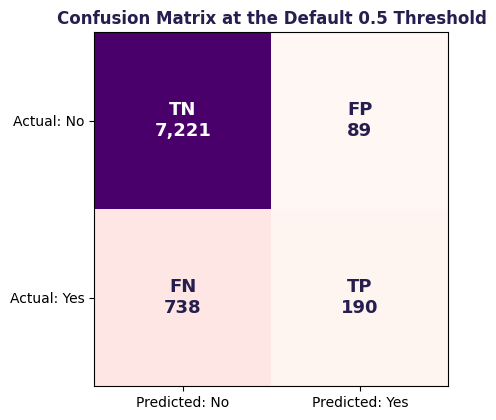

In [4]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.8, 4.3))
im = ax.imshow(cm, cmap="RdPu")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}", ha="center", va="center",
                fontsize=13, color="white" if cm[i, j] > cm.max() / 2 else NAVY, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted: No", "Predicted: Yes"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No", "Actual: Yes"])
ax.set_title("Confusion Matrix at the Default 0.5 Threshold", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()


**Read the bottom row carefully:** of every client who actually would have subscribed, the model correctly caught
only a fraction of them — the rest were predicted "no" right alongside everyone who really was a "no." That's the
number accuracy hides completely, because both are the majority-favored outcome.


## 3. Precision, Recall, F1 — In Plain Terms

- **Recall** — of clients who actually would subscribe, what fraction did we catch?
- **Precision** — of the clients we flagged as likely subscribers, what fraction actually were?
- **F1** — the harmonic mean of the two, a single number that penalizes a model for being lopsided in either
  direction.


In [5]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Value": [model_accuracy, precision, recall, f1],
    "In plain terms": [
        "Barely beats predicting 'no' for everyone",
        "When we flag a client, we're right about 2 times in 3",
        "We're catching roughly 1 in 5 of the clients who'd actually say yes",
        "A single, honest number — and it looks nothing like 90%",
    ],
}).round(4)
metrics_table


,Metric,Value,In plain terms
0,Accuracy,0.8996,Barely beats predicting 'no' for everyone
1,Precision,0.6810,"When we flag a client, we're right about 2 tim..."
2,Recall,0.2047,We're catching roughly 1 in 5 of the clients w...
3,F1,0.3148,"A single, honest number — and it looks nothing..."


**Business framing:** at the default threshold, this model is conservative — it only flags a client when it's
fairly confident (68% precision), but that conservatism costs us 4 out of every 5 clients who would have said yes.
Whether that's the right trade-off depends on what a missed call actually costs versus a wasted one — which is
exactly what Block 7's threshold adjustment tackles directly.


## 4. ROC vs. Precision-Recall — Same Model, Two Very Different Pictures


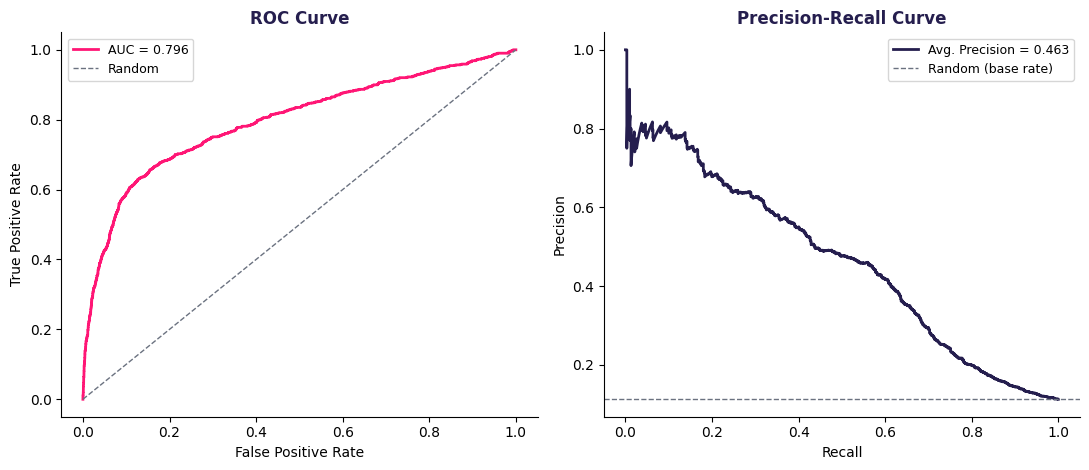

ROC-AUC:              0.796
PR-AUC (avg. precision): 0.463


In [6]:
fpr, tpr, _ = roc_curve(y_test, proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, proba)

roc_auc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

axes[0].plot(fpr, tpr, color=PINK, linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", color=NAVY, fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].plot(rec_curve, prec_curve, color=NAVY, linewidth=2, label=f"Avg. Precision = {pr_auc:.3f}")
axes[1].axhline(y_test.mean(), color=GRAY, linestyle="--", linewidth=1, label="Random (base rate)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", color=NAVY, fontweight="bold")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"ROC-AUC:              {roc_auc:.3f}")
print(f"PR-AUC (avg. precision): {pr_auc:.3f}")


**Same model, same predictions — very different-looking scores.** ROC-AUC's denominator is the false positive
*rate*, measured against a huge pool of true negatives (88.7% of the data) — it's forgiving almost by construction.
Precision-Recall has no such cushion: precision is measured against however many positives the model actually
predicted, so it's exposed to the full weight of the 11.3% base rate. **Under heavy class imbalance, the
Precision-Recall curve is the more honest picture** — worth defaulting to it over ROC whenever a target looks like
ours.


## 5. Hyperparameter Tuning — Properly, This Time

Up to now every model in this course has used `C=0.5` because that's what we picked. Let's actually justify a
choice with cross-validated search instead of a guess — reusing Block 5's leakage-safe `Pipeline` pattern so the
scaler never sees the validation fold during tuning, and holding `X_test` out completely until the very end.


In [7]:
preprocessor = ColumnTransformer(
    [("scale", StandardScaler(), numeric_to_scale)],
    remainder="passthrough",
)
pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=3000, solver="saga")),
])

param_grid = {
    "clf__C": [0.1, 0.5, 2.0],
    "clf__l1_ratio": [0.0, 1.0],  # 0.0 = pure L2, 1.0 = pure L1 (see Block 4)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
grid_search = GridSearchCV(pipe, param_grid, scoring="roc_auc", cv=cv, n_jobs=2)
grid_search.fit(X_train, y_train)
print(f"grid search time: {time.time() - t0:.1f}s")


grid search time: 65.6s


In [8]:
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_clf__C", "param_clf__l1_ratio", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False).reset_index(drop=True)
cv_results.columns = ["C", "l1_ratio", "Mean CV ROC-AUC", "Std across folds"]
cv_results


,C,l1_ratio,Mean CV ROC-AUC,Std across folds
0,0.1,1.0,0.780367,0.006016
1,0.5,1.0,0.779825,0.006077
2,2.0,1.0,0.779660,0.006061
3,2.0,0.0,0.779603,0.006022
4,0.5,0.0,0.779601,0.006029
5,0.1,0.0,0.779475,0.006035


In [9]:
print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
best_proba = best_model.predict_proba(X_test)[:, 1]
tuned_test_auc = roc_auc_score(y_test, best_proba)

print()
print(f"Baseline (C=0.5, L2) test ROC-AUC: {roc_auc:.4f}")
print(f"Tuned    ({grid_search.best_params_}) test ROC-AUC: {tuned_test_auc:.4f}")


Best params: {'clf__C': 0.1, 'clf__l1_ratio': 1.0}
Best CV ROC-AUC: 0.7804

Baseline (C=0.5, L2) test ROC-AUC: 0.7958
Tuned    ({'clf__C': 0.1, 'clf__l1_ratio': 1.0}) test ROC-AUC: 0.7963


**Honest takeaway:** the tuned model edges out the baseline by a fraction of a point — nowhere near the difference
`duration` made in Block 4. Every configuration in the grid landed within about half a percentage point of every
other. On this feature set, `C` and the L1/L2 balance are close to *already* optimized by default values — the
real ceiling on this model's performance is set by what signal exists in the features, not by how carefully the
regularization strength is dialed in. That's still worth knowing precisely: it tells us where to spend effort next
(better features, a different model family) rather than continuing to tune a knob that's already near its limit.


## Recap

- Accuracy on an imbalanced target can look almost identical for a real model and for a model that predicts
  nothing at all — always check what the "do-nothing" baseline scores before trusting an accuracy number.
- Precision, recall, and F1 turn "90% accurate" into an honest, specific claim: this model is conservative — high
  precision, low recall — at its default threshold.
- ROC-AUC and PR-AUC can diverge sharply under class imbalance; PR is the more trustworthy read here.
- Hyperparameter tuning done right is cross-validated and leakage-safe — but it isn't guaranteed to move the
  needle, and knowing that for certain is itself a useful, reportable result.
- No new CSV from this block — `bank_marketing_features.csv` carries forward unchanged.

**Up next — Block 7:** Evaluating Models — Threshold Adjustment & Class Imbalance. We just found that this model
misses 4 out of 5 real "yes" clients at the default 0.5 threshold — Block 7 is where we do something about it.
